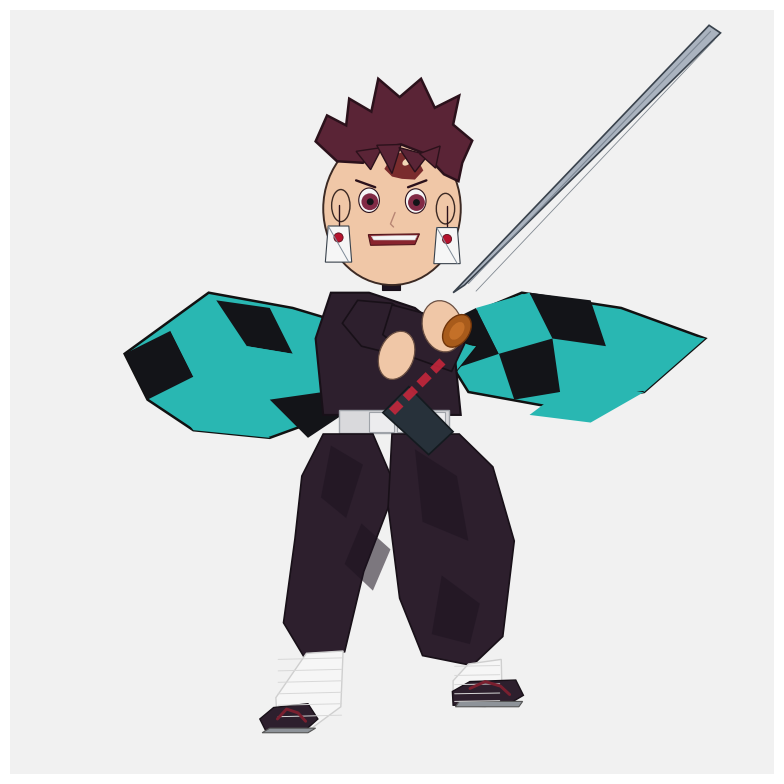

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon, Ellipse, Circle, Rectangle, PathPatch
from matplotlib.path import Path

# -----------------------------
# 기본 설정
# -----------------------------
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect("equal")
ax.axis("off")

# -----------------------------
# 배경
# -----------------------------
ax.add_patch(Rectangle((0, 0), 100, 100, facecolor="#f1f1f1", edgecolor="none"))

# -----------------------------
# 색상 팔레트
# -----------------------------
skin = "#f0c7a7"
hair = "#5a2436"
hair_edge = "#2b111b"
uniform = "#2d1f2d"
uniform_shadow = "#1d1320"
teal = "#29b7b2"
dark_teal = "#12363b"
black = "#131418"
white = "#f6f6f6"
gray = "#d8d8d8"
belt_gray = "#d9d9dc"
belt_dark = "#9fa3a9"
sandal_red = "#7a1f2f"
metal = "#6f7b88"
metal_dark = "#39424c"
orange = "#a85b1b"

# -----------------------------
# 유틸 함수
# -----------------------------
def add_checkered_polygon(points, color1=teal, color2=black, edgecolor="#111111", lw=1.8):
    """
    단순 체크 패턴 느낌을 위해 기본 폴리곤을 채운 뒤,
    내부에 추가 삼각/사각 폴리곤을 올려 분위기를 냄
    """
    ax.add_patch(Polygon(points, closed=True, facecolor=color1, edgecolor=edgecolor, lw=lw))

def draw_earring(x, y, scale=1.0):
    ax.plot([x, x], [y + 2.5 * scale, y + 6 * scale], color=hair_edge, lw=1.0)
    poly = Polygon([
        (x - 1.8 * scale, y + 2.3 * scale),
        (x + 1.8 * scale, y + 2.3 * scale),
        (x + 2.3 * scale, y - 4.0 * scale),
        (x - 2.3 * scale, y - 4.0 * scale),
    ], closed=True, facecolor=white, edgecolor=metal_dark, lw=0.8)
    ax.add_patch(poly)
    ax.add_patch(Circle((x, y + 0.3 * scale), 0.8 * scale, facecolor="#b5132e", edgecolor="#5a0c19", lw=0.6))
    ax.plot([x - 1.8 * scale, x + 1.8 * scale], [y + 2.3 * scale, y - 4.0 * scale], color="#7e8a97", lw=0.7)

def draw_sword():
    # 검날
    blade = Polygon([
        (58, 63), (59.5, 64), (93, 97), (91.5, 98)
    ], closed=True, facecolor="#aab3bf", edgecolor="#39424c", lw=1.2)
    ax.add_patch(blade)

    # 하몬 느낌
    ax.plot([60, 91.7], [64.2, 97.2], color="#727d8a", lw=0.8, alpha=0.8)
    ax.plot([61, 92.2], [63.2, 96.1], color="#515c68", lw=0.6, alpha=0.7)

    # 손잡이
    handle = Polygon([
        (48.8, 47.3), (52.2, 50.7), (58.0, 44.8), (54.8, 41.8)
    ], closed=True, facecolor="#27313a", edgecolor="#141a1f", lw=1.2)
    ax.add_patch(handle)

    # 손잡이 랩 느낌
    for t in [
        [(49.6, 47.8), (50.7, 48.9), (51.5, 48.1), (50.4, 47.0)],
        [(51.4, 49.6), (52.6, 50.8), (53.4, 50.0), (52.2, 48.8)],
        [(53.2, 51.4), (54.4, 52.6), (55.2, 51.8), (54.0, 50.6)],
        [(55.0, 53.2), (56.2, 54.4), (57.0, 53.6), (55.8, 52.4)],
    ]:
        ax.add_patch(Polygon(t, closed=True, facecolor="#ce273c", edgecolor="none", alpha=0.85))

    # 가드(츠바)
    ax.add_patch(Ellipse((58.5, 58), 4.7, 3.2, angle=55, facecolor=orange, edgecolor="#6f340a", lw=1.0))
    ax.add_patch(Ellipse((58.5, 58), 2.6, 1.6, angle=55, facecolor="#d17a2e", edgecolor="none", alpha=0.7))

def draw_face():
    # 얼굴
    ax.add_patch(Ellipse((50, 74), 18, 20, facecolor=skin, edgecolor="#3c2a24", lw=1.4))

    # 귀
    ax.add_patch(Ellipse((43.3, 74.4), 2.4, 4.2, facecolor=skin, edgecolor="#3c2a24", lw=1.0))
    ax.add_patch(Ellipse((57.0, 74.0), 2.4, 4.0, facecolor=skin, edgecolor="#3c2a24", lw=1.0))

    # 눈
    ax.add_patch(Ellipse((47.0, 75.1), 2.7, 3.2, facecolor=white, edgecolor=hair_edge, lw=0.8))
    ax.add_patch(Ellipse((53.1, 75.0), 2.7, 3.2, facecolor=white, edgecolor=hair_edge, lw=0.8))
    ax.add_patch(Circle((47.1, 74.9), 1.1, facecolor="#812a45", edgecolor="none"))
    ax.add_patch(Circle((53.2, 74.8), 1.1, facecolor="#812a45", edgecolor="none"))
    ax.add_patch(Circle((47.15, 74.9), 0.45, facecolor=black, edgecolor="none"))
    ax.add_patch(Circle((53.2, 74.8), 0.45, facecolor=black, edgecolor="none"))

    # 눈썹
    ax.plot([45.3, 47.8], [77.7, 76.8], color=hair_edge, lw=1.7)
    ax.plot([52.1, 54.5], [76.8, 77.7], color=hair_edge, lw=1.7)

    # 코
    ax.plot([50.4, 49.8, 50.2], [73.5, 72.0, 71.6], color="#b88674", lw=1.0)

    # 입 / 이빨
    mouth = Polygon([
        (47.2, 69.2), (53.0, 69.3), (53.6, 70.7), (46.9, 70.6)
    ], closed=True, facecolor="#89242e", edgecolor="#53161c", lw=0.8)
    ax.add_patch(mouth)
    teeth = Polygon([
        (47.3, 70.4), (53.3, 70.5), (53.0, 69.9), (47.6, 69.9)
    ], closed=True, facecolor=white, edgecolor="#cccccc", lw=0.4)
    ax.add_patch(teeth)

    # 이마 상처/문양
    scar = Polygon([
        (49.0, 79.2), (50.1, 81.0), (52.0, 81.6), (53.3, 80.5),
        (54.1, 79.0), (53.0, 77.8), (51.3, 77.9), (50.0, 78.2)
    ], closed=True, facecolor="#7a2c2d", edgecolor="none")
    ax.add_patch(scar)
    ax.add_patch(Ellipse((51.9, 80.1), 1.2, 0.8, angle=35, facecolor="#f2d7b7", edgecolor="none"))

def draw_hair():
    hair_points = [
        (42.8, 80.2), (40.0, 82.8), (41.5, 86.2), (44.0, 84.9),
        (44.4, 88.4), (47.3, 86.7), (48.2, 91.0), (51.0, 88.6),
        (53.8, 91.0), (55.6, 87.2), (58.8, 88.8), (58.0, 85.0),
        (60.5, 82.9), (59.2, 80.0), (58.7, 77.6), (56.8, 78.5),
        (54.3, 81.2), (51.2, 82.4), (48.8, 82.0), (46.2, 80.0)
    ]
    ax.add_patch(Polygon(hair_points, closed=True, facecolor=hair, edgecolor=hair_edge, lw=1.8))

    # 앞머리
    bangs = [
        [(45.3, 81.5), (47.2, 79.1), (48.7, 82.0)],
        [(48.0, 82.3), (50.0, 78.6), (51.2, 82.4)],
        [(50.9, 82.0), (53.0, 78.8), (54.7, 81.0)],
        [(53.6, 81.2), (55.7, 79.3), (56.3, 82.2)],
    ]
    for tri in bangs:
        ax.add_patch(Polygon(tri, closed=True, facecolor=hair, edgecolor=hair_edge, lw=1.0))

def draw_haori():
    # 왼쪽 큰 망토
    left = [
        (15, 55), (26, 63), (37, 61), (47, 58), (45, 48),
        (34, 44), (24, 45), (18, 49)
    ]
    add_checkered_polygon(left)

    # 왼쪽 체크 무늬
    for poly, color in [
        ([(15, 55), (21, 58), (24, 52), (18, 49)], black),
        ([(21, 58), (27, 62), (31, 56), (24, 52)], teal),
        ([(27, 62), (34, 61), (37, 55), (31, 56)], black),
        ([(31, 56), (37, 55), (41, 50), (34, 49)], teal),
        ([(34, 49), (41, 50), (45, 48), (39, 44)], black),
        ([(24, 45), (34, 44), (30, 50), (21, 49)], teal),
    ]:
        ax.add_patch(Polygon(poly, closed=True, facecolor=color, edgecolor="none"))

    # 오른쪽 큰 망토
    right = [
        (55, 58), (67, 63), (80, 61), (91, 57), (83, 50), (71, 48), (60, 50)
    ]
    add_checkered_polygon(right)

    for poly, color in [
        ([(55, 58), (61, 61), (64, 55), (58, 53)], black),
        ([(61, 61), (68, 63), (71, 57), (64, 55)], teal),
        ([(68, 63), (76, 62), (78, 56), (71, 57)], black),
        ([(78, 56), (85, 58), (91, 57), (83, 50)], teal),
        ([(64, 55), (71, 57), (72, 50), (66, 49)], black),
        ([(72, 50), (83, 50), (76, 46), (68, 47)], teal),
    ]:
        ax.add_patch(Polygon(poly, closed=True, facecolor=color, edgecolor="none"))

    # 몸 앞쪽으로 지나가는 천
    front_cloth = [(41, 57), (52, 59), (61, 56), (57, 51), (45, 51)]
    add_checkered_polygon(front_cloth, color1=teal, color2=black, lw=1.4)
    ax.add_patch(Polygon([(41, 57), (47, 58.5), (49, 54), (45, 51)], closed=True, facecolor=black, edgecolor="none"))
    ax.add_patch(Polygon([(49, 54), (56, 56.5), (61, 56), (57, 51)], closed=True, facecolor=teal, edgecolor="none"))

def draw_body():
    # 상체
    torso = Polygon([
        (42, 63), (47, 63), (53, 61), (58, 57),
        (59, 47), (41, 47), (40, 57)
    ], closed=True, facecolor=uniform, edgecolor="#181018", lw=1.5)
    ax.add_patch(torso)

    # 소매/팔
    left_arm = Polygon([
        (45.5, 62), (50.0, 61.6), (54.2, 58.5), (52.0, 54.5), (46.0, 56.0), (43.5, 59.0)
    ], closed=True, facecolor=uniform, edgecolor="#181018", lw=1.2)
    right_arm = Polygon([
        (50.0, 61.4), (55.3, 60.0), (59.5, 56.3), (57.8, 52.7), (52.5, 54.6), (48.8, 57.5)
    ], closed=True, facecolor=uniform, edgecolor="#181018", lw=1.2)
    ax.add_patch(left_arm)
    ax.add_patch(right_arm)

    # 손
    ax.add_patch(Ellipse((50.6, 54.8), 4.5, 6.5, angle=-20, facecolor=skin, edgecolor="#6a4f42", lw=0.9))
    ax.add_patch(Ellipse((56.6, 58.6), 5.2, 6.8, angle=15, facecolor=skin, edgecolor="#6a4f42", lw=0.9))

    # 목깃
    ax.add_patch(Rectangle((48.7, 63.3), 2.4, 2.5, facecolor=uniform_shadow, edgecolor="#181018", lw=0.8))
    ax.add_patch(Rectangle((48.7, 65.0), 2.4, 0.4, facecolor=gray, edgecolor="none"))

    # 허리 벨트
    ax.add_patch(Rectangle((43, 44.6), 14.5, 3.0, facecolor=belt_gray, edgecolor=belt_dark, lw=1.0))
    ax.add_patch(Rectangle((47.0, 44.7), 3.2, 2.7, facecolor="#ececee", edgecolor=belt_dark, lw=0.8))
    ax.add_patch(Rectangle((50.7, 44.7), 1.7, 2.7, facecolor="#ececee", edgecolor=belt_dark, lw=0.8))
    ax.add_patch(Rectangle((52.9, 44.7), 4.0, 2.7, facecolor="#ececee", edgecolor=belt_dark, lw=0.8))

    # 하의 - 왼쪽
    left_pants = Polygon([
        (41, 44.5), (47.5, 44.5), (50.5, 37.5), (46.3, 26.5),
        (43.8, 16.0), (38.5, 15.3), (35.8, 19.8), (37.3, 30.8), (38.2, 39.0)
    ], closed=True, facecolor=uniform, edgecolor="#181018", lw=1.2)
    ax.add_patch(left_pants)

    # 하의 - 오른쪽
    right_pants = Polygon([
        (50.0, 44.5), (58.8, 44.5), (63.2, 40.2), (66.0, 30.5),
        (64.5, 18.0), (60.5, 14.2), (54.0, 15.5), (51.0, 23.0), (49.5, 35.0)
    ], closed=True, facecolor=uniform, edgecolor="#181018", lw=1.2)
    ax.add_patch(right_pants)

    # 하의 그림자 / 주름
    shadow_polys = [
        [(42.0, 43.0), (46.2, 40.5), (44.0, 33.5), (40.7, 36.2)],
        [(46.0, 32.8), (49.8, 29.4), (47.5, 24.0), (43.8, 27.5)],
        [(53.0, 42.5), (58.5, 39.0), (60.0, 30.5), (54.0, 33.0)],
        [(56.5, 26.0), (61.5, 22.3), (60.2, 17.0), (55.2, 18.3)],
    ]
    for poly in shadow_polys:
        ax.add_patch(Polygon(poly, closed=True, facecolor=uniform_shadow, edgecolor="none", alpha=0.55))

def draw_legs_and_feet():
    # 왼쪽 다리 붕대
    left_wrap = Polygon([
        (38.8, 15.8), (43.6, 16.1), (43.3, 8.8), (39.5, 6.0), (35.0, 6.2), (34.8, 10.0)
    ], closed=True, facecolor=white, edgecolor="#cfcfcf", lw=1.0)
    ax.add_patch(left_wrap)

    for y in [15.0, 13.5, 12.0, 10.5, 9.0, 7.5]:
        ax.plot([35.1, 43.4], [y, y + 0.2], color="#d8d8d8", lw=0.7)

    # 오른쪽 다리 붕대
    right_wrap = Polygon([
        (60.0, 14.4), (64.3, 15.0), (64.4, 10.5), (62.2, 8.8), (58.0, 9.1), (58.0, 12.2)
    ], closed=True, facecolor=white, edgecolor="#cfcfcf", lw=1.0)
    ax.add_patch(right_wrap)

    for y in [14.1, 12.9, 11.7, 10.5, 9.5]:
        ax.plot([58.2, 64.1], [y, y + 0.1], color="#d8d8d8", lw=0.7)

    # 왼쪽 발
    left_foot = Polygon([
        (33.5, 5.6), (38.5, 5.6), (40.3, 7.2), (39.0, 9.2),
        (34.5, 8.7), (32.7, 7.2)
    ], closed=True, facecolor=uniform, edgecolor="#181018", lw=1.0)
    ax.add_patch(left_foot)
    ax.add_patch(Polygon([
        (33.0, 5.4), (39.0, 5.4), (40.0, 6.0), (34.0, 6.0)
    ], closed=True, facecolor="#8e9399", edgecolor="#555", lw=0.8))
    ax.plot([35.0, 36.2, 37.7, 38.7], [7.2, 8.5, 8.0, 6.9], color=sandal_red, lw=2.1)

    # 오른쪽 발
    right_foot = Polygon([
        (58.0, 9.0), (65.0, 9.0), (67.2, 10.3), (66.2, 12.3),
        (60.2, 12.1), (57.9, 10.8)
    ], closed=True, facecolor=uniform, edgecolor="#181018", lw=1.0)
    ax.add_patch(right_foot)
    ax.add_patch(Polygon([
        (58.3, 8.8), (66.6, 8.8), (67.1, 9.5), (58.8, 9.5)
    ], closed=True, facecolor="#8e9399", edgecolor="#555", lw=0.8))
    ax.plot([60.2, 62.2, 64.2, 65.4], [11.2, 12.1, 11.5, 10.4], color=sandal_red, lw=2.1)

# -----------------------------
# 실제 그리기 순서
# -----------------------------
draw_haori()
draw_body()
draw_legs_and_feet()
draw_face()
draw_hair()
draw_earring(43.0, 70.0, scale=0.75)
draw_earring(57.2, 69.8, scale=0.75)
draw_sword()

# -----------------------------
# 저장 및 출력
# -----------------------------
plt.tight_layout()
plt.show()

# 필요시 저장:
# plt.savefig("tanjiro_matplotlib_style.png", dpi=200, bbox_inches="tight", pad_inches=0.05)

In [2]:

from pathlib import Path
import pandas as pd
DATA_DIR = Path("data/raw")
customers = pd.read_csv(DATA_DIR / "customers.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv")

In [3]:

order_items = order_items.copy()
order_items["line_total"] = (
    order_items["quantity"]
    * order_items["unit_price"]
)

In [7]:
print(order_items.info())
print(
      order_items["line_total"] ==
      order_items["quantity"]* order_items["unit_price"].sum()
)

<class 'pandas.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   order_item_id  764 non-null    int64
 1   order_id       764 non-null    int64
 2   product_id     764 non-null    int64
 3   quantity       764 non-null    int64
 4   unit_price     764 non-null    int64
 5   line_total     764 non-null    int64
dtypes: int64(6)
memory usage: 35.9 KB
None
0      False
1      False
2      False
3      False
4      False
       ...  
759    False
760    False
761    False
762    False
763    False
Length: 764, dtype: bool


In [8]:
completed_orders = orders[
    orders["order_status"].eq("completed")
].copy()

In [9]:
completed_orders.head()

,order_id,customer_id,order_date,payment_method,order_status
0,1,123,2026-07-10,card,completed
5,6,87,2026-05-24,naver_pay,completed
8,9,145,2026-03-25,card,completed
10,11,47,2026-01-20,card,completed
11,12,98,2025-09-14,kakao_pay,completed


In [10]:
visualization_df = (
    order_items
    .merge(
        completed_orders,
        on="order_id",
        how="inner",
        validate="many_to_one",
    )
    .merge(
        products[["product_id", "product_name", "category"]],
        on="product_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        customers[["customer_id", "age", "gender", "city"]],
        on="customer_id",
        how="left",
        validate="many_to_one",
    )

)
visualization_df["order_date"] = pd.to_datetime(
    visualization_df["order_date"],
    errors="coerce",
)

visualization_df["order_month"] = (
    visualization_df["order_date"]
    .dt.to_period("M")
    .astype(str)

)

In [12]:
print(visualization_df.shape)

display(visualization_df.head())

(474, 16)


,order_item_id,order_id,product_id,quantity,unit_price,line_total,customer_id,order_date,payment_method,order_status,product_name,category,age,gender,city,order_month
0,1,1,100,3,102000,306000,123,2026-07-10,card,completed,도서 상품 100,도서,20,M,서울,2026-07
1,2,1,87,5,25000,125000,123,2026-07-10,card,completed,도서 상품 087,도서,20,M,서울,2026-07
2,3,1,7,3,142000,426000,123,2026-07-10,card,completed,도서 상품 007,도서,20,M,서울,2026-07
3,4,1,9,3,193000,579000,123,2026-07-10,card,completed,스포츠 상품 009,스포츠,20,M,서울,2026-07
4,13,6,83,3,24000,72000,87,2026-05-24,naver_pay,completed,전자기기 상품 083,전자기기,31,M,울산,2026-05


In [13]:

monthly_summary = (
    visualization_df
    .groupby("order_month", as_index=False)
    .agg(
        total_amount=("line_total", "sum"),
        order_count=("order_id", "nunique"),
    )
    .sort_values("order_month")
)

In [15]:
print(monthly_summary.head())
print(monthly_summary["order_month"].min())
print(monthly_summary["order_month"].max())

  order_month  total_amount  order_count
0     2025-09       4453000            7
1     2025-10      17037000           19
2     2025-11       9955000           12
3     2025-12      23474000           24
4     2026-01      11339000           15
2025-09
2026-09


In [16]:
category_summary = (

    visualization_df

    .groupby("category", as_index=False)

    .agg(

        total_amount=("line_total", "sum"),

        total_quantity=("quantity", "sum"),

        order_count=("order_id", "nunique"),
    )
    .sort_values("total_amount", ascending=False)
)


In [17]:

product_summary = (

    visualization_df

    .groupby(["product_id", "product_name"], as_index=False)

    .agg(

        total_amount=("line_total", "sum"),

        total_quantity=("quantity", "sum"),

        order_count=("order_id", "nunique"),

    )

    .sort_values("total_amount", ascending=False)

)

In [18]:

order_summary = (

    visualization_df

    .groupby("order_id", as_index=False)

    .agg(

        order_date=("order_date", "first"),

        payment_method=("payment_method", "first"),

        age=("age", "first"),

        city=("city", "first"),

        order_total=("line_total", "sum"),

        total_quantity=("quantity", "sum"),

    )

)


In [19]:
payment_summary = (

    order_summary

    .groupby("payment_method", as_index=False)

    .agg(order_count=("order_id", "nunique"))

    .sort_values("order_count", ascending=False)

)

In [20]:

display(monthly_summary)

display(category_summary)

display(product_summary.head(10))

display(order_summary.head())


,order_month,total_amount,order_count
0,2025-09,4453000,7
1,2025-10,17037000,19
2,2025-11,9955000,12
3,2025-12,23474000,24
4,2026-01,11339000,15
5,2026-02,7435000,10
6,2026-03,18933000,24
7,2026-04,11521000,18
8,2026-05,13135000,14
9,2026-06,15713000,20


,category,total_amount,total_quantity,order_count
3,스포츠,31743000,295,85
5,전자기기,26400000,259,60
2,생활용품,23915000,272,65
1,뷰티,23383000,223,65
4,식품,16573000,133,36
0,도서,16389000,149,52
6,패션,10587000,111,33


,product_id,product_name,total_amount,total_quantity,order_count
39,41,스포츠 상품 041,5705000,35,12
11,12,식품 상품 012,4375000,25,7
8,9,스포츠 상품 009,3860000,20,6
70,72,뷰티 상품 072,3780000,20,6
69,71,전자기기 상품 071,3703000,23,5
66,68,스포츠 상품 068,3640000,26,8
78,81,전자기기 상품 081,3630000,22,6
10,11,패션 상품 011,3565000,31,7
20,22,생활용품 상품 022,3248000,29,8
86,89,생활용품 상품 089,3090000,30,11


,order_id,order_date,payment_method,age,city,order_total,total_quantity
0,1,2026-07-10,card,20,서울,1436000,14
1,6,2026-05-24,naver_pay,31,울산,1309000,15
2,9,2026-03-25,card,59,성남,236000,3
3,11,2026-01-20,card,36,울산,222000,3
4,12,2025-09-14,kakao_pay,61,인천,444000,6


In [24]:

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


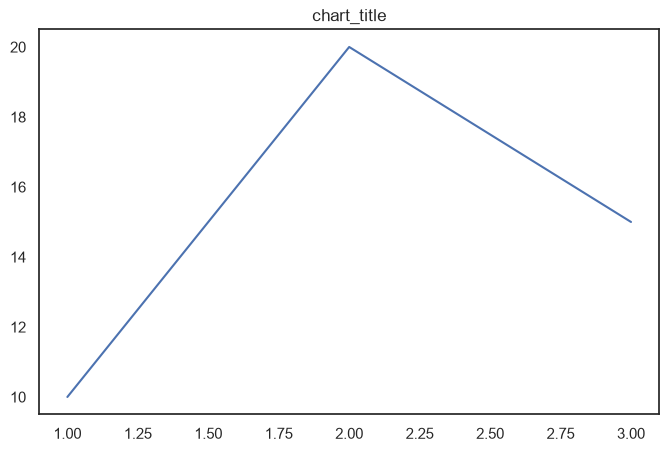

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot([1, 2, 3], [10, 20, 15])
plt.title("chart_title")
plt.show()

In [22]:
category_summary.info()

<class 'pandas.DataFrame'>
Index: 7 entries, 3 to 6
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   category        7 non-null      str  
 1   total_amount    7 non-null      int64
 2   total_quantity  7 non-null      int64
 3   order_count     7 non-null      int64
dtypes: int64(3), str(1)
memory usage: 338.0 bytes


C:\Users\apll1\AppData\Local\Temp\ipykernel_15804\3521361926.py:19: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\apll1\AppData\Local\Temp\ipykernel_15804\3521361926.py:19: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\apll1\AppData\Local\Temp\ipykernel_15804\3521361926.py:19: UserWarning: Glyph 52768 (\N{HANGUL SYLLABLE CEU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\apll1\AppData\Local\Temp\ipykernel_15804\3521361926.py:19: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\apll1\AppData\Local\Temp\ipykernel_15804\3521361926.py:19: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\apll1\AppData\Local\Temp\ipykernel_15804\3521361926.py:19: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.tight_lay

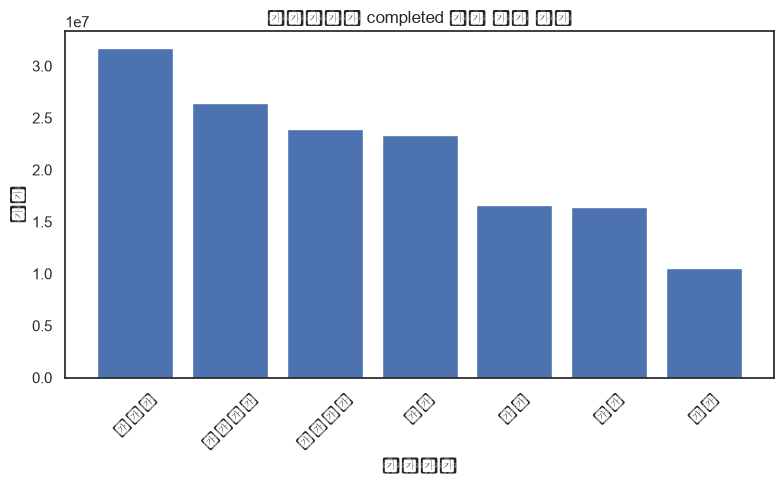

In [23]:

plt.figure(figsize=(8, 5))

plt.bar(

    category_summary["category"],

    category_summary["total_amount"],

)

plt.title("카테고리별 completed 주문 기준 금액")

plt.xlabel("카테고리")

plt.ylabel("금액")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


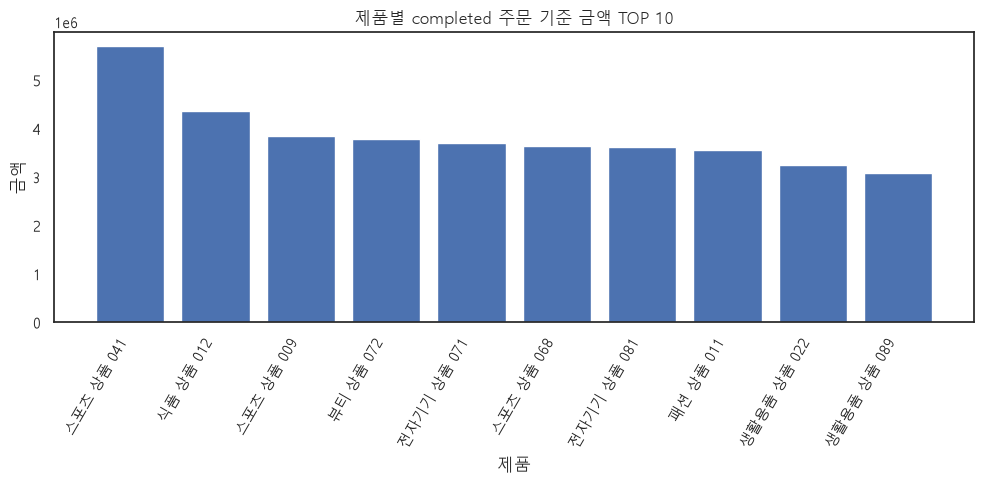

In [25]:
top10_products = product_summary.head(10)

plt.figure(figsize=(10, 5))

plt.bar(

    top10_products["product_name"],

    top10_products["total_amount"],

)

plt.title("제품별 completed 주문 기준 금액 TOP 10")

plt.xlabel("제품")

plt.ylabel("금액")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.show()

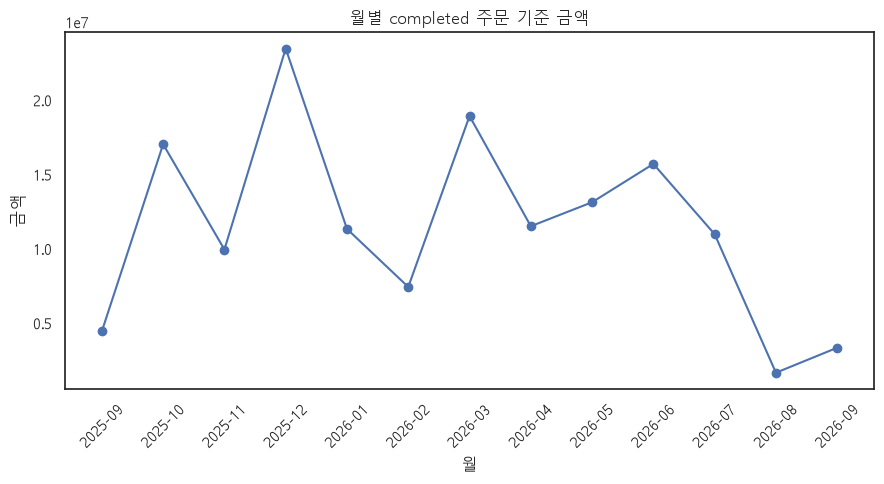

In [26]:

plt.figure(figsize=(9, 5))

plt.plot(

    monthly_summary["order_month"],

    monthly_summary["total_amount"],

    marker="o",

)

plt.title("월별 completed 주문 기준 금액")

plt.xlabel("월")

plt.ylabel("금액")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

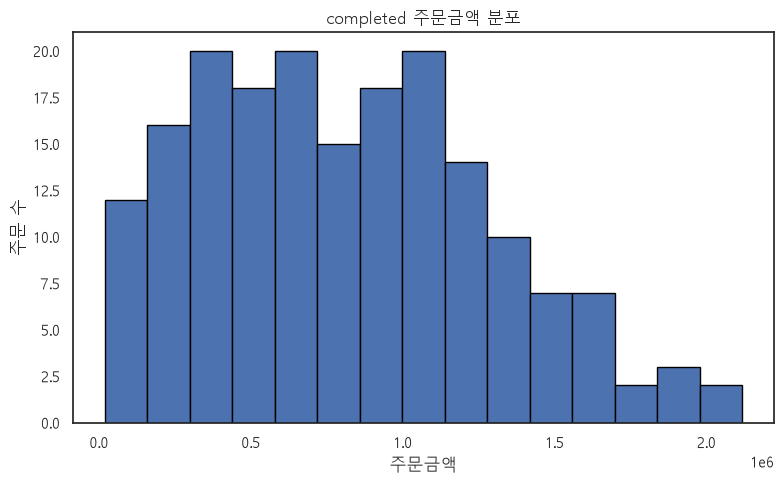

In [27]:

plt.figure(figsize=(8, 5))

plt.hist(

    order_summary["order_total"],

    bins=15,

    edgecolor="black",

)

plt.title("completed 주문금액 분포")

plt.xlabel("주문금액")

plt.ylabel("주문 수")

plt.tight_layout()

plt.show()

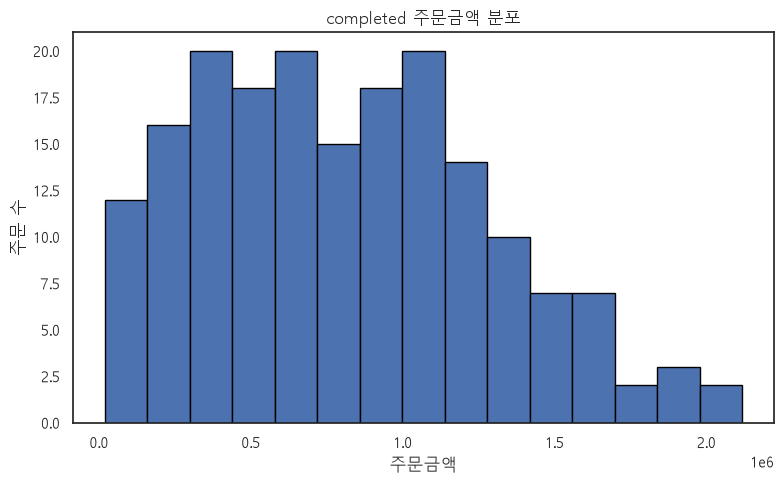

In [28]:

plt.figure(figsize=(8, 5))

plt.hist(

    order_summary["order_total"],

    bins=15,

    edgecolor="black",

)

plt.title("completed 주문금액 분포")

plt.xlabel("주문금액")

plt.ylabel("주문 수")

plt.tight_layout()

plt.show()

In [29]:
payment_summary.describe()

,order_count
count,4.000000
mean,46.000000
std,5.291503
min,39.000000
25%,43.500000
50%,47.000000
75%,49.500000
max,51.000000


<Figure size 900x500 with 0 Axes>

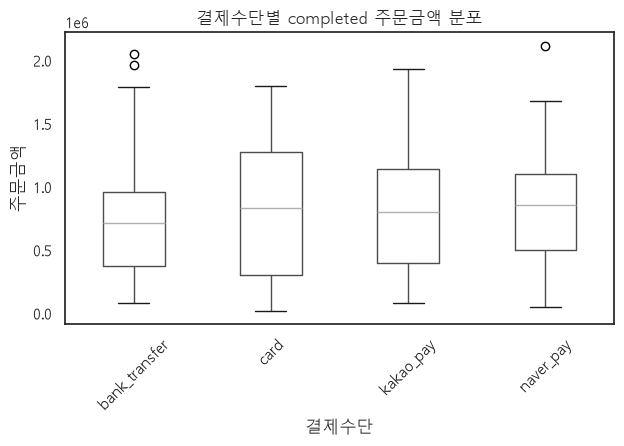

In [30]:
plt.figure(figsize=(9, 5))

order_summary.boxplot(

    column="order_total",

    by="payment_method",

    grid=False,

)

plt.title("결제수단별 completed 주문금액 분포")

plt.suptitle("")

plt.xlabel("결제수단")

plt.ylabel("주문금액")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()
